<a href="https://colab.research.google.com/github/SerynaPayne/Seryna_INFO4670_Spring2026/blob/main/Seryna_Payne_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [124]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')

Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> A False Positive is the more costly error in a real spam filter as it is more important that the user receives important messages and has to ignore spam messages rather than risking whether they receive important messages for filtering more spam messages. One real-world consequence for a costly False Positive error is if a user was told to be expecting to hear from the company they interviewed with via SMS, but the message being flagged as spam and they consequently miss the job opportunity. An example of a costly False Negative error is if the user unknowingly follows a link that was sent to them via SMS, not knowing it was spam and putting themselves at risk for a virus.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> In order to account for False Positive error, Precision should be the primary evaluation metric. This measures the fraction of SMS messages classified as spam that were actually spam, which we want to focus on to ensure that ham messages do not get classified as spam.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> The accuracy that a dummy model that always predicts "ham" achieves would be 87%. This is a misleading number due to the "accuracy trap" that describes a model having high accuracy simply because they do not predict any positives. This dataset would have 87% accuracy because the ham rate in the dataset is 87% - because more of the SMS messages are ham than spam, it appears that the dataset is accurate where in reality, it does not predict spam at all.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [125]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


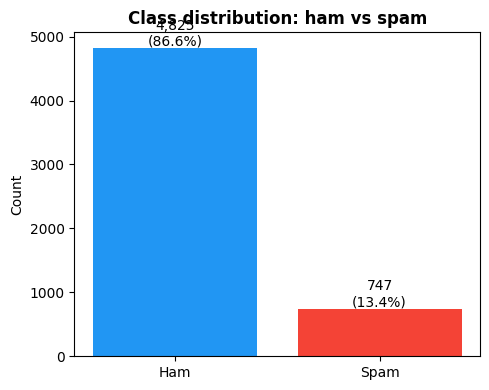

In [126]:
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [127]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


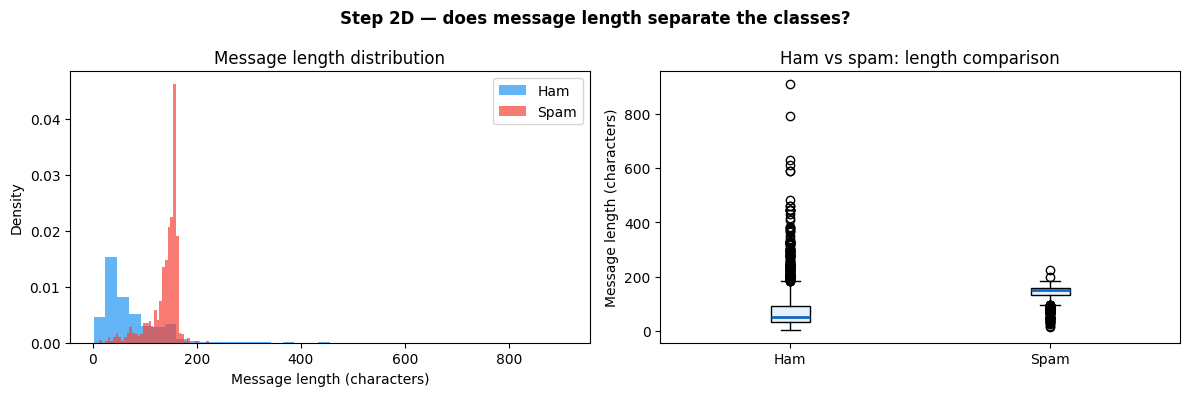

In [128]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [129]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [130]:
def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    # contains a URL (www)
    d['has_url'] = msg.str.contains(r'www', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    # contains selection words
    d['has_selection'] = msg.str.contains(r'\b(guaranteed|selected|congratulations)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_url                13.1%    0.1%  +13.1%
has_selection          11.1%    0.1%  +11.0%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


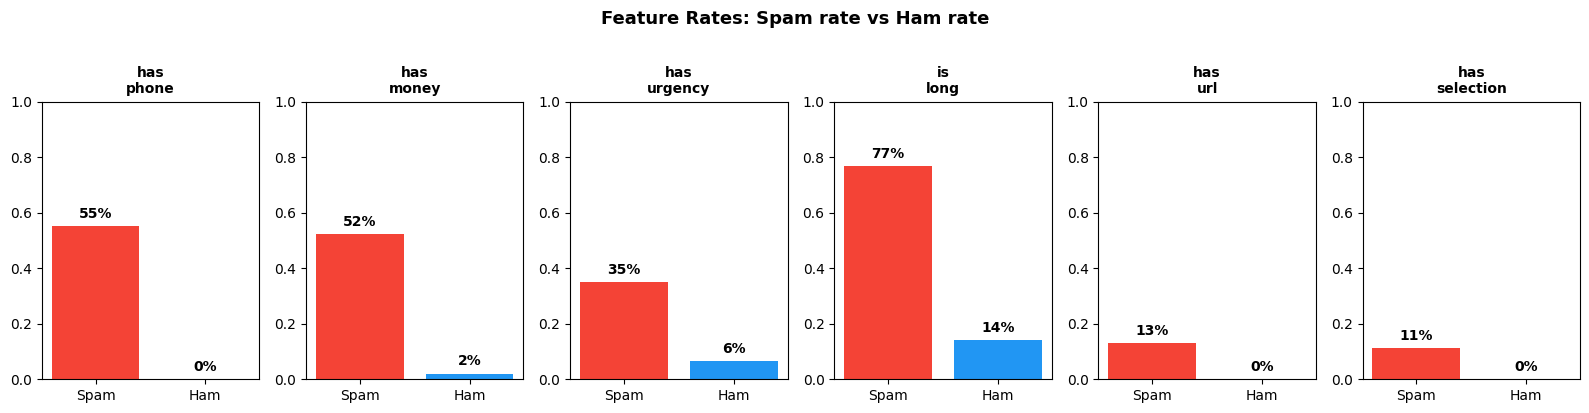

In [131]:
# visualize feature gaps
fig, axes = plt.subplots(1, 6, figsize=(16, 4))
for i, feat in enumerate(feature_cols):
    fr = df[df['spam']==1][feat].mean()
    lr = df[df['spam']==0][feat].mean()
    axes[i].bar(['Spam','Ham'], [fr, lr], color=['#F44336','#2196F3'])
    axes[i].set_title(feat.replace('_','\n'), fontsize=10, fontweight='bold')
    axes[i].set_ylim(0, 1)
    for j, v in enumerate([fr, lr]):
        axes[i].text(j, v+0.03, f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Feature Rates: Spam rate vs Ham rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
>The first feature I added was whether the message contains a url by detecting www. I expected this to be a useful spam signal because typically, spam messages will either encourage you to call a number or follow a link. I think that users are more likely to follow a link than to call a number, which can lead to dangerous viruses or payments. Because of this, I focused on finding whether the message contained a url in order to help detect spam messages.

*Feature 2 — name and explanation:*
> The second feature I added was whether the message contains selection indicators with the detection of the words guaranteed, selected, and congratulations. From personal experience, I have found that spam messages often contain these, prompting me to follow their instructions to collect a "prize." Working together with the has_money feature, I think that this is a useful spam signal.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The feature that has the largest gap between spam and ham is whether the message is long, with a difference of 63% between spam and ham. A large gap matters when selecting a root node for a Decision Tree because we want to select the attribute with the highest information gain. This reduces entropy, or uncertainty, in the Decision Tree by creating more pure subsets. If there was a smaller gap in selecting a root node, there would be greater uncertainty with a mixed class.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> An example of spam messages that my features would fail to catch include those with call-to-action features, such as example 1 with "text FA to 87121 to receive entry question." However, other features that I have would catch other parts of the message, such as the has_money feature catching "free entry in 2 a wkly comp to win" with the words "free" and "win." It would be helpful to add another feature for the call-to-action words however, such as "text" or "reply," as this is used often in spam messages.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [132]:
# set x and y
X = df[feature_cols].values
y = df['spam'].values

# use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# print the size of each split and the spam rate
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Train spam rate:", y_train.mean())
print("Test spam rate:", y_test.mean())

Train size: 4179, Test size: 1393
Train spam rate: 0.13400335008375208
Test spam rate: 0.1342426417803302


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We pass 'stratify=y' in order to maintain the proportion of classes in the training and testing sets. In an imbalanced dataset like this, it is likely that the model would be non-representative and pull too many spam or too many ham examples in the test, making the training set imbalanced. As we discussed with the accurracy trap, because the spam is the minority, it is possible that without stratify=y, spam may not show up at all in the test or training sets.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> A situation where cross-validation would be preferable over a single split would be when using small datasets and when we're concerned about overfitting. In cross-validation, we reduce variance by averaging over many splits instead of relying on a single split and we can make sure that each fold maintains the class distribution.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 14


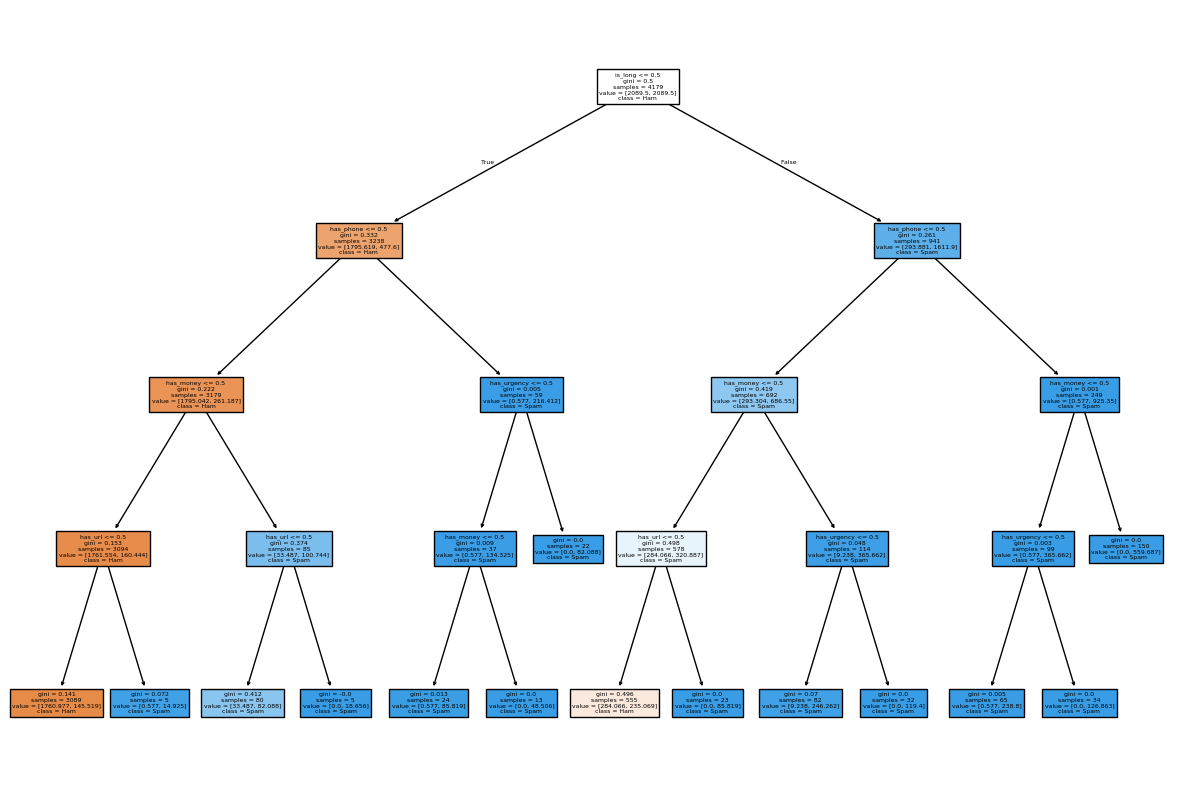

|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_url <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_url >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone 

In [133]:
# decision tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')

# fit on the training set
tree.fit(X_train, y_train)

# print the number of leaves
print(f"Number of leaves: {tree.get_n_leaves()}")

# visualize tree
plt.figure(figsize=(15, 10))
plot_tree(tree, feature_names=feature_cols, class_names=['Ham', 'Spam'], filled=True)
plt.show()

# print the text rules
print(export_text(tree, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


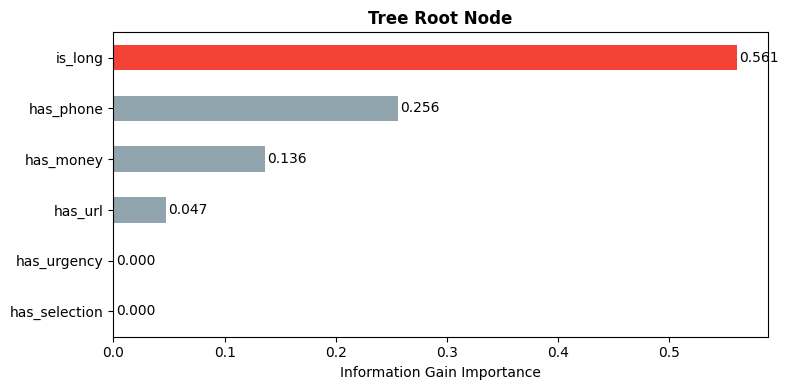

In [134]:
# get .feature_importances from tree
importances = pd.Series(tree.feature_importances_, index=feature_cols).sort_values()

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#F44336' if v == importances.max() else '#90A4AE' for v in importances]
importances.plot(kind='barh', ax=ax, color=bar_colors)
ax.set_xlabel('Information Gain Importance')
ax.set_title('Tree Root Node', fontweight='bold')
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


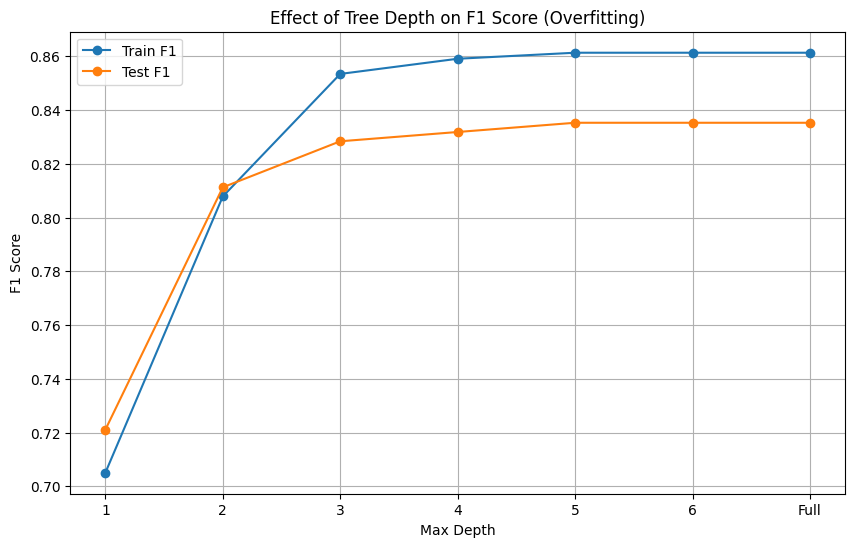

The gap between train and test F1 starts to widen at a depth of 3.


In [135]:
# loop over depths
depths = [1, 2, 3, 4, 5, 6, None]
depth_labels = ['1', '2', '3', '4', '5', '6', 'Full']
train_f1 = []
test_f1 = []

for depth in depths:
    # train the tree
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    # record train_f1 and test_f1
    train_f1.append(f1_score(y_train, clf.predict(X_train)))
    test_f1.append(f1_score(y_test, clf.predict(X_test)))

# plot both lines on the same axes
plt.figure(figsize=(10, 6))
plt.plot(depth_labels, train_f1, label='Train F1', marker='o')
plt.plot(depth_labels, test_f1, label='Test F1', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Effect of Tree Depth on F1 Score (Overfitting)')
plt.legend()
plt.grid(True)
plt.show()

# identify where the gap between train and test F1 starts to widen
print("The gap between train and test F1 starts to widen at a depth of 3.")

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [136]:
# Naive Bayes and fit on the training set
nb = BernoulliNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


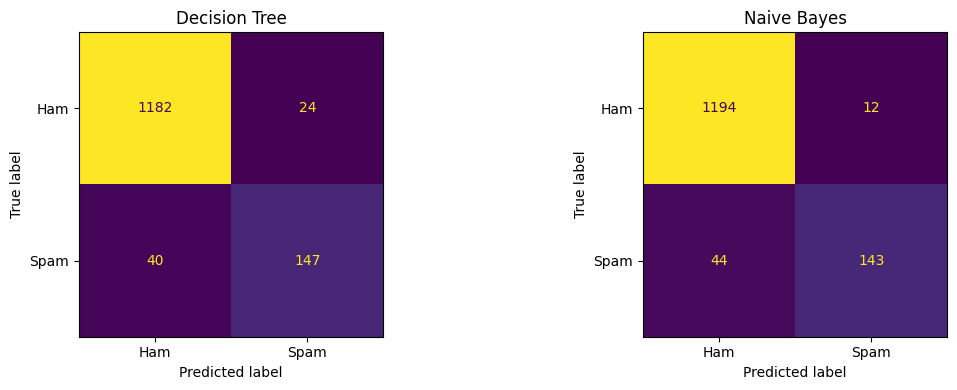

Decision Tree:
  TP: 147
  FP: 24
  FN: 40
  TN: 1182
Naive Bayes:
  TP: 143
  FP: 12
  FN: 44
  TN: 1194


In [137]:
# get predictions from both y_pred_dt and y_pred_nb
y_pred_dt = tree.predict(X_test)
y_pred_nb = nb.predict(X_test)

# plot two confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, ax=axes[0], display_labels=['Ham', 'Spam'], colorbar=False)
ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, ax=axes[1], display_labels=['Ham', 'Spam'], colorbar=False)
axes[0].set_title('Decision Tree')
axes[1].set_title('Naive Bayes')
plt.tight_layout()
plt.show()

# print TP, FP, FN, TN for each model
print('Decision Tree:')
print(f'  TP: {confusion_matrix(y_test, y_pred_dt)[1, 1]}')
print(f'  FP: {confusion_matrix(y_test, y_pred_dt)[0, 1]}')
print(f'  FN: {confusion_matrix(y_test, y_pred_dt)[1, 0]}')
print(f'  TN: {confusion_matrix(y_test, y_pred_dt)[0, 0]}')
print('Naive Bayes:')
print(f'  TP: {confusion_matrix(y_test, y_pred_nb)[1, 1]}')
print(f'  FP: {confusion_matrix(y_test, y_pred_nb)[0, 1]}')
print(f'  FN: {confusion_matrix(y_test, y_pred_nb)[1, 0]}')
print(f'  TN: {confusion_matrix(y_test, y_pred_nb)[0, 0]}')


### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


               Precision  Recall  F1-Score  Accuracy
Model                                               
Decision Tree      0.857   0.810     0.833     0.956
Naive Bayes        0.942   0.778     0.852     0.964
Random Forest      0.817   0.834     0.825     0.953


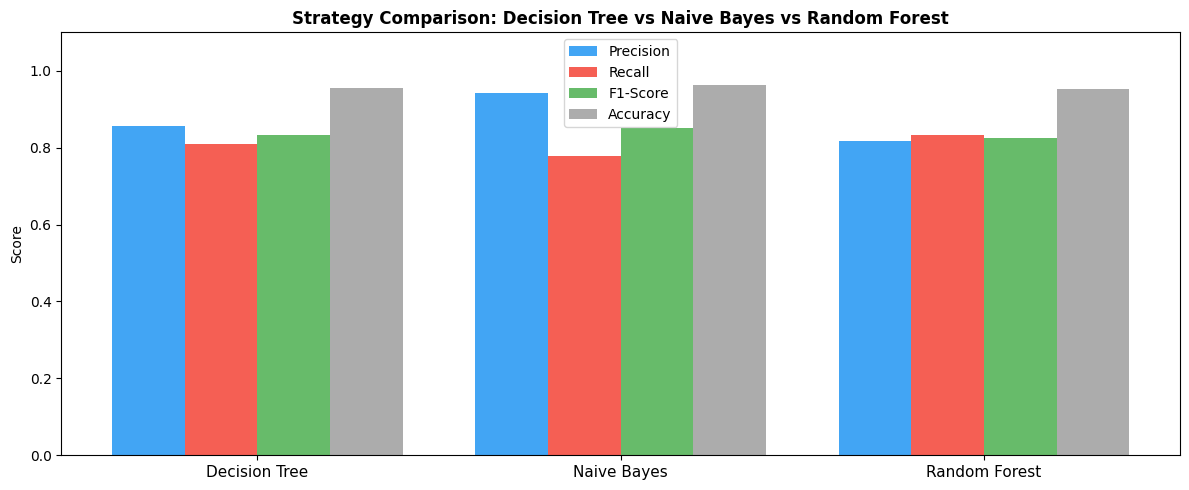

In [140]:
# Because the assignment did not ask for us to create a rule set, that will not be included in the grouped bar chart. However, I will create a random forest metric in order to add more comparison.
# create random forest metric
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results = []
for name, yt, yp in [
    ('Decision Tree',   y,      tree.predict(X)),
    ('Naive Bayes',     y,      nb.predict(X)),
    ('Random Forest', y_test, y_pred_rf),
]:
    results.append({
        'Model':     name,
        'Precision': precision_score(yt, yp, zero_division=0),
        'Recall':    recall_score(yt, yp, zero_division=0),
        'F1-Score':  f1_score(yt, yp, zero_division=0),
        'Accuracy':  accuracy_score(yt, yp),
    })

# build DataFrame
res_df = pd.DataFrame(results).set_index('Model')
print(res_df.round(3).to_string())

# grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(res_df))
w = 0.2
for i, (col, color) in enumerate([
    ('Precision','#2196F3'), ('Recall','#F44336'), ('F1-Score','#4CAF50'), ('Accuracy','#9E9E9E')
]):
    ax.bar(x + i*w, res_df[col], w, label=col, color=color, alpha=0.85)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(res_df.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Strategy Comparison: Decision Tree vs Naive Bayes vs Random Forest',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [139]:
# use stratified k fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# run cross_val_score
dt_f1 = cross_val_score(tree, X, y, cv=skf, scoring='f1')
nb_f1 = cross_val_score(nb, X, y, cv=skf, scoring='f1')

# print average F1
print(f'Decision Tree average F1: {dt_f1.mean():.3f}')
print(f'Naive Bayes average F1:   {nb_f1.mean():.3f}')

Decision Tree average F1: 0.833
Naive Bayes average F1:   0.852


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> 147 spam messages were correctly caught.
> 40 spam messages slipped through.
> 24 legitimate messages were wrongly blocked.

*Naive Bayes:*
> 143 spam messages were correctly caught.
> 44 spam messages slipped through.
> 12 legitimate messages were wrongly blocked.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> The model that wins on precision, the metric I chose in Step 1, is the Naive Bayes model. Because I think the False Positive is a more costly error, the model that wrongly blocked less legitimate messages has the best precision. In this case, the Naive Bayes only blocked 12 legitimate messages whereas the Decision Tree blocked 24 legitimate messages. The cross-validation result in 6C also confirms this, with the Naive Bayes model having a higher F1 score.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend the Naive Bayes model because of it's high Precision and F1-Score. Looking at the results in 6B we can see that the precision for Naive Bays is 94.2% with an F1 of 85.2% while the Decision Tree is 85.7% with an F1 of 83.3%. However, the Naive Bayes model has a lower recall than the Decision Tree model, meaning it detects less spam as seen in 4 more spam messages slipping through than the Decision Tree. One improvement that can be made includes adding more data and refining data pre-processing with integration.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> One feature that would likely fail on modern spam is the has_url feature. As stated, modern spam typically uses legitimate-looking URLs and many legitimate messages would also include URLs. The second feature that would likely fail on modern spam is the is_long feature as modern spam has gotten smarter with sounding like legitimate messages, making messages shorter to seem legitimate. Along with this, many legitimate messages will be long. This is why it is so important to have multiple features working together in order to create an effective model.
